# Budget Phasing Walkthrough

Notebook 01 showed the problem: when TV, Meta, and Search spend are all correlated, OLS elasticity estimates are unreliable. The same market gives wildly different answers depending on which period of data you happened to use.

This notebook shows the fix. `BudgetPhaser` takes your historical spend (multiple years) and your upcoming plan year, then finds the optimal amount of independent weekly variation to introduce into the plan-year channel mix — while keeping monthly budgets intact.

**Why does history matter?** An MMM is fit on 3–5 years of data, not just the plan year. Even if the plan year is beautifully de-correlated, four years of correlated history will dilute the benefit. `BudgetPhaser` accounts for this by evaluating each candidate phasing against the *full* dataset, using a weighted OLS that upweights the plan year so the model learns more from the de-correlated data.

The output is a concrete week-by-week schedule you can hand to your media agency.

In [1]:
FAST_MODE = False  # set False for publication-quality runs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong_is_your_mmm import CollinearityDiagnostic, BudgetPhaser, simulate_spend
from how_wrong_is_your_mmm._phaser import _compute_weights, _generate_phased_schedule, _get_month_labels

## The data

We simulate four years of weekly historical spend (208 weeks) plus one year of plan spend (52 weeks), all with high inter-channel correlation — the realistic scenario where an MMM struggles.

The `start_date` gives both DataFrames a proper `DatetimeIndex`, required by `BudgetPhaser` so it knows which weeks belong to which month.

In [3]:
history = simulate_spend(n_obs=208, correlation=0.7, seed=0, start_date='2019-01-07')
plan    = simulate_spend(n_obs=52,  correlation=0.7, seed=1, start_date='2023-01-09')

print(f'History: {history.shape[0]} weeks  ({history.index[0].date()} to {history.index[-1].date()})')
print(f'Plan:    {plan.shape[0]} weeks  ({plan.index[0].date()} to {plan.index[-1].date()})')
print()
print('Plan channel spend:')
for ch in plan.columns:
    print(f'  {ch.upper():6s}  mean weekly: £{plan[ch].mean():,.0f}  annual: £{plan[ch].sum():,.0f}')
print()
print('Correlation matrix (plan year):')
print(plan.corr().round(2))

History: 208 weeks  (2019-01-07 to 2022-12-26)
Plan:    52 weeks  (2023-01-09 to 2024-01-01)

Plan channel spend:
  TV      mean weekly: £98,031  annual: £5,097,606
  META    mean weekly: £78,190  annual: £4,065,889
  SEARCH  mean weekly: £59,621  annual: £3,100,269

Correlation matrix (plan year):
          tv  meta  search
tv      1.00  0.68    0.68
meta    0.68  1.00    0.67
search  0.68  0.67    1.00


## Baseline unreliability

Before recommending any changes, we establish how unreliable the current situation is. We run `CollinearityDiagnostic` on the full 5-year dataset (history + unphased plan) to show what the MMM would produce today.

In [4]:
n_sims = 10 if FAST_MODE else 50

combined_baseline = pd.concat([history, plan])
baseline = CollinearityDiagnostic(
    spend_df=combined_baseline,
    true_elasticities={'tv': 0.3, 'meta': 0.5, 'search': 0.4},
)
baseline.fit(n_sims=n_sims, fast_mode=FAST_MODE)
print('Baseline (history + unphased plan, equal weights):')
print(baseline.summary().to_string(index=False))

Baseline (history + unphased plan, equal weights):
channel  true_elasticity  mean_estimated  std_estimated  mean_error_pct  coef_of_variation
   meta              0.5          0.4969         0.1175         -0.6216             0.2364
 search              0.4          0.4251         0.1486          6.2725             0.3497
     tv              0.3          0.2948         0.0948         -1.7338             0.3216


## Running BudgetPhaser

The phaser grid-searches over a phasing amplitude alpha in [0, 1]:

- **alpha = 0** — no change from original plan
- **alpha = 1** — maximum allowed weekly deviation (40% per channel by default)

For each alpha it generates a phased schedule — redistributing each channel's weekly spend within each month, monthly totals exactly preserved — then runs a **weighted** `CollinearityDiagnostic` on history + phased plan.

### Weighting schemes

Because history is correlated and fixed, we need the model to learn more from the plan year than from the history. Three schemes are available:

| scheme | effect |
|---|---|
| `"uniform"` | all observations equally weighted — baseline, ignores the history problem |
| `"binary"` | plan year gets weight `plan_weight` (default 5), history gets 1 — simple and interpretable |
| `"decay"` | exponential decay from most recent week, `half_life` controls the rate |

`"binary"` is the default: it tells the model the plan year counts 5x as much as any history week.

In [5]:
grid_steps = 10 if FAST_MODE else 20

phaser = BudgetPhaser(
    history_df=history,
    plan_df=plan,
    true_elasticities={'tv': 0.3, 'meta': 0.5, 'search': 0.4},
    weighting='binary',
    plan_weight=5.0,
    max_weekly_deviation_pct=40.0,
)
phaser.fit(n_sims=n_sims, grid_steps=grid_steps, fast_mode=FAST_MODE)
print(phaser.summary().to_string(index=False))

 alpha  actual_correlation  max_cv  max_monthly_deviation_pct  cv_tv  cv_meta  cv_search
0.0000              0.6942  0.3569                        0.0 0.3569   0.2909     0.3447
0.0526              0.6946  0.3637                        0.0 0.3637   0.2893     0.3389
0.1053              0.6921  0.3569                        0.0 0.3569   0.2913     0.3432
0.1579              0.6934  0.3550                        0.0 0.3448   0.2923     0.3550
0.2105              0.6948  0.3567                        0.0 0.3567   0.2847     0.3553
0.2632              0.6862  0.3928                        0.0 0.3928   0.3107     0.3577
0.3158              0.6818  0.3854                        0.0 0.3414   0.2924     0.3854
0.3684              0.6820  0.3915                        0.0 0.3565   0.3027     0.3915
0.4211              0.6847  0.3708                        0.0 0.3708   0.2844     0.3680
0.4737              0.6853  0.4132                        0.0 0.3289   0.2789     0.4132
0.5263              0

## The CV curve

The chart shows how elasticity reliability (max CV across channels) and inter-channel correlation change as phasing amplitude increases. The green dashed line marks the recommended alpha.

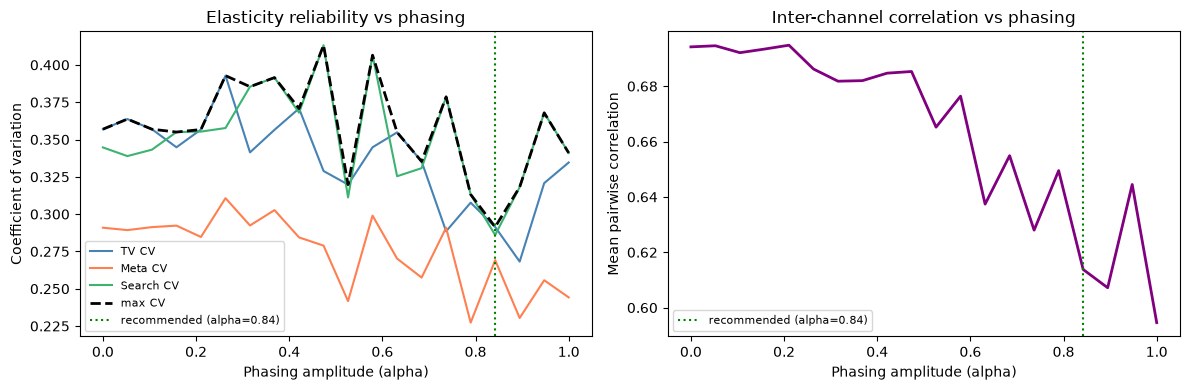

In [6]:
results = phaser.summary()
rec = phaser.recommend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(results['alpha'], results['cv_tv'], color='steelblue', label='TV CV')
ax.plot(results['alpha'], results['cv_meta'], color='coral', label='Meta CV')
ax.plot(results['alpha'], results['cv_search'], color='mediumseagreen', label='Search CV')
ax.plot(results['alpha'], results['max_cv'], color='black', linewidth=2,
        linestyle='--', label='max CV')
ax.axvline(rec['alpha'], color='green', linestyle=':', linewidth=1.5,
           label=f"recommended (alpha={rec['alpha']:.2f})")
ax.set_xlabel('Phasing amplitude (alpha)')
ax.set_ylabel('Coefficient of variation')
ax.set_title('Elasticity reliability vs phasing')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(results['alpha'], results['actual_correlation'], color='purple', linewidth=2)
ax.axvline(rec['alpha'], color='green', linestyle=':', linewidth=1.5,
           label=f"recommended (alpha={rec['alpha']:.2f})")
ax.set_xlabel('Phasing amplitude (alpha)')
ax.set_ylabel('Mean pairwise correlation')
ax.set_title('Inter-channel correlation vs phasing')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## How phasing affects elasticity estimates

CV is a useful metric, but this chart makes the improvement tangible. We run `CollinearityDiagnostic` at three phasing levels — no phasing (alpha=0), the recommended alpha, and maximum phasing (alpha=1) — using the same weighted OLS as the phaser. The distribution of estimated elasticities across simulation seeds is plotted against the true value.

Narrower spread = more reliable model.

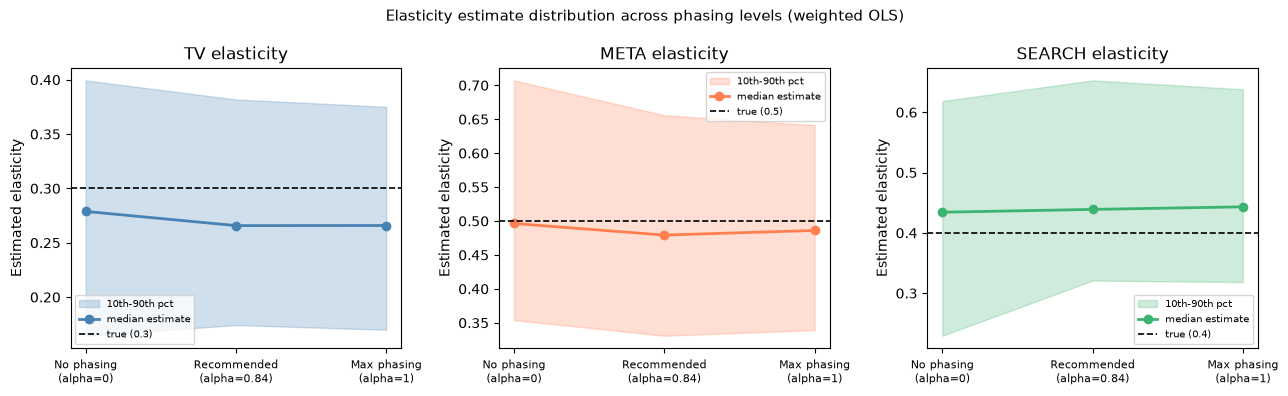

In [7]:
month_labels = _get_month_labels(plan)
true_elasticities = {'tv': 0.3, 'meta': 0.5, 'search': 0.4}
best_alpha = phaser.recommend()['alpha']

# precompute weights — same scheme as the phaser used
weights = _compute_weights(
    n_history=len(history),
    n_plan=len(plan),
    weighting=phaser.weighting,
    plan_weight=phaser.plan_weight,
    half_life=phaser.half_life,
)

alpha_levels = {
    f'No phasing\n(alpha=0)': 0.0,
    f'Recommended\n(alpha={best_alpha:.2f})': best_alpha,
    f'Max phasing\n(alpha=1)': 1.0,
}

elast_data = {}
for label, alpha in alpha_levels.items():
    phased = _generate_phased_schedule(
        plan, month_labels, alpha=alpha,
        max_weekly_deviation_pct=phaser.max_weekly_deviation_pct, seed=99,
    )
    combined = pd.concat([history, phased])
    diag = CollinearityDiagnostic(
        spend_df=combined,
        true_elasticities=true_elasticities,
        weights=weights,
    )
    diag.fit(n_sims=n_sims)
    elast_data[label] = {
        ch: diag.results_[diag.results_['channel'] == ch]['estimated_elasticity'].to_numpy()
        for ch in plan.columns
    }

channel_colors = {'tv': 'steelblue', 'meta': 'coral', 'search': 'mediumseagreen'}
labels = list(alpha_levels.keys())
x = range(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, ch in zip(axes, plan.columns):
    color = channel_colors[ch]
    true_val = true_elasticities[ch]
    medians = [float(np.median(elast_data[l][ch])) for l in labels]
    p10s    = [float(np.percentile(elast_data[l][ch], 10)) for l in labels]
    p90s    = [float(np.percentile(elast_data[l][ch], 90)) for l in labels]

    ax.fill_between(x, p10s, p90s, alpha=0.25, color=color, label='10th-90th pct')
    ax.plot(x, medians, color=color, linewidth=2, marker='o', label='median estimate')
    ax.axhline(true_val, color='black', linestyle='--', linewidth=1.2, label=f'true ({true_val})')
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'{ch.upper()} elasticity')
    ax.set_ylabel('Estimated elasticity')
    ax.legend(fontsize=7)

plt.suptitle('Elasticity estimate distribution across phasing levels (weighted OLS)', fontsize=11)
plt.tight_layout()
plt.show()

## The recommendation

In [8]:
rec = phaser.recommend()
baseline_row = phaser.summary().iloc[0]
cv_reduction = 100 * (baseline_row['max_cv'] - rec['max_cv']) / baseline_row['max_cv']
max_dev_pct = phaser.max_weekly_deviation_pct * rec['alpha']

print('Recommendation')
print('=' * 60)
print(f"Phasing amplitude:             alpha = {rec['alpha']:.2f}")
print(f"Max weekly deviation:          +/-{max_dev_pct:.0f}% of original weekly spend per channel")
print()
print(f"Correlation (combined, alpha=0):  {baseline_row['actual_correlation']:.2f}")
print(f"Correlation (combined, recommended): {rec['actual_correlation']:.2f}")
print()
print(f"Max CV (alpha=0):              {baseline_row['max_cv']:.3f}")
print(f"Max CV (recommended):          {rec['max_cv']:.3f}")
print(f"CV reduction:                  {cv_reduction:.0f}%")

Recommendation
Phasing amplitude:             alpha = 0.84
Max weekly deviation:          +/-34% of original weekly spend per channel

Correlation (combined, alpha=0):  0.69
Correlation (combined, recommended): 0.61

Max CV (alpha=0):              0.357
Max CV (recommended):          0.291
CV reduction:                  18%


## The recommended schedule

The recommended schedule is a concrete 52-week spend plan for the plan year. Monthly totals are preserved exactly — the only change is how the budget is paced week-to-week within each month.

In [9]:
sched = phaser.recommended_schedule_

orig_monthly = plan.resample('ME').sum().round(0)
new_monthly  = sched.resample('ME').sum().round(0)

print('Monthly totals — original plan vs recommended (GBP):')
print()
for ch in plan.columns:
    print(f'{ch.upper()}')
    comparison = pd.DataFrame({'original': orig_monthly[ch], 'recommended': new_monthly[ch]})
    comparison['difference'] = comparison['recommended'] - comparison['original']
    print(comparison.to_string())
    print()

Monthly totals — original plan vs recommended (GBP):

TV
            original  recommended  difference
2023-01-31  404382.0     404382.0         0.0
2023-02-28  419169.0     419169.0         0.0
2023-03-31  401598.0     401598.0         0.0
2023-04-30  393877.0     393877.0         0.0
2023-05-31  457592.0     457592.0         0.0
2023-06-30  406658.0     406658.0         0.0
2023-07-31  444907.0     444907.0         0.0
2023-08-31  436890.0     436890.0         0.0
2023-09-30  386524.0     386524.0         0.0
2023-10-31  489900.0     489900.0         0.0
2023-11-30  332245.0     332245.0         0.0
2023-12-31  431467.0     431467.0         0.0
2024-01-31   92397.0      92397.0         0.0

META
            original  recommended  difference
2023-01-31  315177.0     315177.0         0.0
2023-02-28  351718.0     351718.0         0.0
2023-03-31  345464.0     345464.0         0.0
2023-04-30  302241.0     302241.0         0.0
2023-05-31  387597.0     387597.0         0.0
2023-06-30  28512

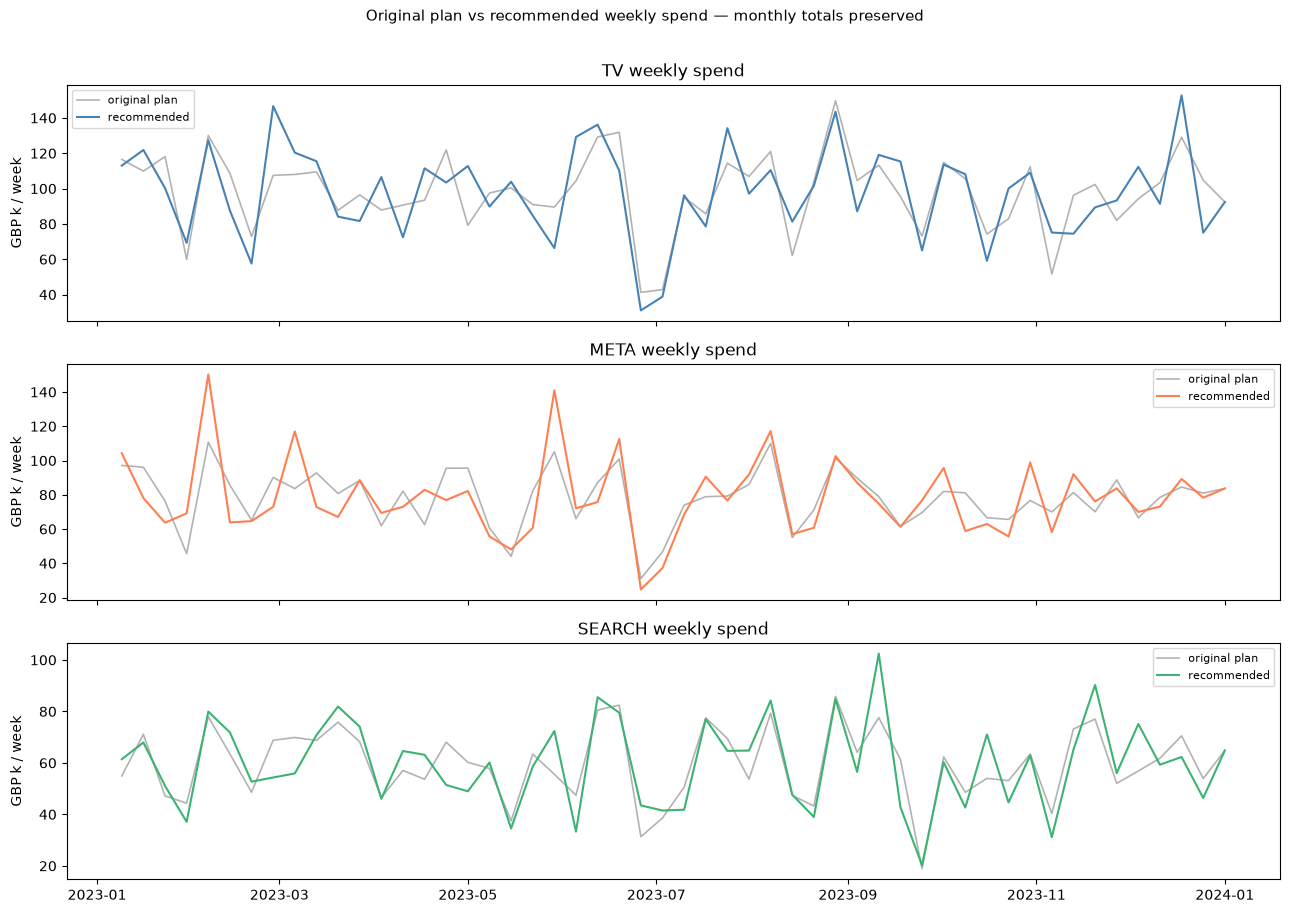

In [10]:
channels_cfg = [
    ('tv',     'steelblue'),
    ('meta',   'coral'),
    ('search', 'mediumseagreen'),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for ax, (ch, color) in zip(axes, channels_cfg):
    ax.plot(plan.index,  plan[ch]  / 1000, color='grey',  alpha=0.6, linewidth=1.2, label='original plan')
    ax.plot(sched.index, sched[ch] / 1000, color=color, linewidth=1.5, label='recommended')
    ax.set_ylabel('GBP k / week')
    ax.set_title(f'{ch.upper()} weekly spend')
    ax.legend(fontsize=8)

plt.suptitle('Original plan vs recommended weekly spend — monthly totals preserved',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## What this achieves

The recommended schedule introduces independent variation in the weekly channel mix — some weeks TV gets a larger share of its monthly budget, others less — while Meta and Search follow their own independent patterns. Monthly commitments are unchanged.

The evaluation is honest: it accounts for four years of correlated history by upweighting the plan year in the OLS. The CV reduction shown above is what a practitioner can realistically expect from their MMM after adopting the phased schedule, not a best-case figure computed on the plan year alone.

Try `weighting='decay'` or `weighting='uniform'` to compare schemes. `uniform` gives the lower bound (no upweighting), `binary` and `decay` give increasingly honest estimates of the benefit under realistic MMM fitting conditions.